# KMeans v2 — CWRU by_fault_type — Comparaison exp_077 vs exp_090

| Champ | Valeur |
|-------|--------|
| **Expérience ancienne** | exp_077 — K=2 fixe, seuil cross-tâche |
| **Expérience nouvelle** | exp_090 — K=silhouette, seuil par tâche |
| **Scénario** | by_fault_type : Ball → Inner Race → Outer Race (3 tâches) |
| **Sprint** | 13 — analyse paramètres non supervisés CWRU |

**Changements testés :**
- `k_method: fixed → silhouette` — K sélectionné automatiquement par score silhouette
- Seuil recalibré par tâche (vs. seuil cross-tâche de la dernière tâche entraînée)

**Conclusion attendue :** est-ce que les paramètres bloquaient l'apprentissage ou la limite est-elle fondamentale ?

In [5]:
import json, os, sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

_cwd = Path('.').resolve()
if _cwd.name == 'cwru_by_fault_type': os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == 'cl_eval': os.chdir(_cwd.parent.parent)
elif _cwd.name == 'notebooks': os.chdir(_cwd.parent)
REPO_ROOT = Path('.').resolve()
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))

OLD_DIR = REPO_ROOT / 'experiments/exp_077_kmeans_cwru_by_fault_type/results'
NEW_DIR = REPO_ROOT / 'experiments/exp_090_kmeans_cwru_by_fault_type_v2/results'
FIGURES_DIR = REPO_ROOT / 'notebooks/figures/cl_evaluation/kmeans/cwru/by_fault_type_v2'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TASK_NAMES = ['Ball', 'Inner Race', 'Outer Race']

old = json.loads((OLD_DIR / 'metrics_cl.json').read_text())
new = json.loads((NEW_DIR / 'metrics_cl.json').read_text())
print('Chargement OK')

Chargement OK


In [6]:
# Section 2 — Comparaison métriques CL

def fmt(v, pct=False):
    return f'{v:.4f}' if not pct else f'{v*100:.1f}%'

table = f"""
| Métrique | exp_077 (K=2 fixe, seuil cross-tâche) | exp_090 (K=silhouette, seuil par tâche) | Delta |
|----------|-----------------------------------------|-----------------------------------------|-------|
| **AA (avg accuracy)** | {fmt(old['acc_final'])} | {fmt(new['acc_final'])} | {new['acc_final']-old['acc_final']:+.4f} |
| **AF (avg forgetting)** | {fmt(old['avg_forgetting'])} | {fmt(new['avg_forgetting'])} | {new['avg_forgetting']-old['avg_forgetting']:+.4f} |
| **BWT** | {old['backward_transfer']:+.4f} | {new['backward_transfer']:+.4f} | {new['backward_transfer']-old['backward_transfer']:+.4f} |
| **RAM peak** | {old['ram_peak_bytes']:,} B | {new['ram_peak_bytes']:,} B | — |
| **n_params** | {old['n_params']} | {new['n_params']} | — |
| **K sélectionné (tâche 0)** | 2 (fixe) | {new['k_selected_per_task'][0]} (silhouette) | — |
| **K sélectionné (tâche 1)** | 2 (fixe) | {new['k_selected_per_task'][1]} (silhouette) | — |
| **K sélectionné (tâche 2)** | 2 (fixe) | {new['k_selected_per_task'][2]} (silhouette) | — |
"""
display(Markdown(table))

print('\nSeuils par tâche (exp_090):')
for k, v in new['thresholds_per_task'].items():
    print(f'  Task {k}: {v:.4f}')


| Métrique | exp_077 (K=2 fixe, seuil cross-tâche) | exp_090 (K=silhouette, seuil par tâche) | Delta |
|----------|-----------------------------------------|-----------------------------------------|-------|
| **AA (avg accuracy)** | 0.1515 | 0.2727 | +0.1212 |
| **AF (avg forgetting)** | 0.0195 | 0.2078 | +0.1883 |
| **BWT** | +0.0390 | +0.2208 | +0.1818 |
| **RAM peak** | 5,432 B | 5,432 B | — |
| **n_params** | 18 | 18 | — |
| **K sélectionné (tâche 0)** | 2 (fixe) | 2 (silhouette) | — |
| **K sélectionné (tâche 1)** | 2 (fixe) | 2 (silhouette) | — |
| **K sélectionné (tâche 2)** | 2 (fixe) | 2 (silhouette) | — |



Seuils par tâche (exp_090):
  Task 0: 3.8864
  Task 1: 6.1163
  Task 2: 12.4634


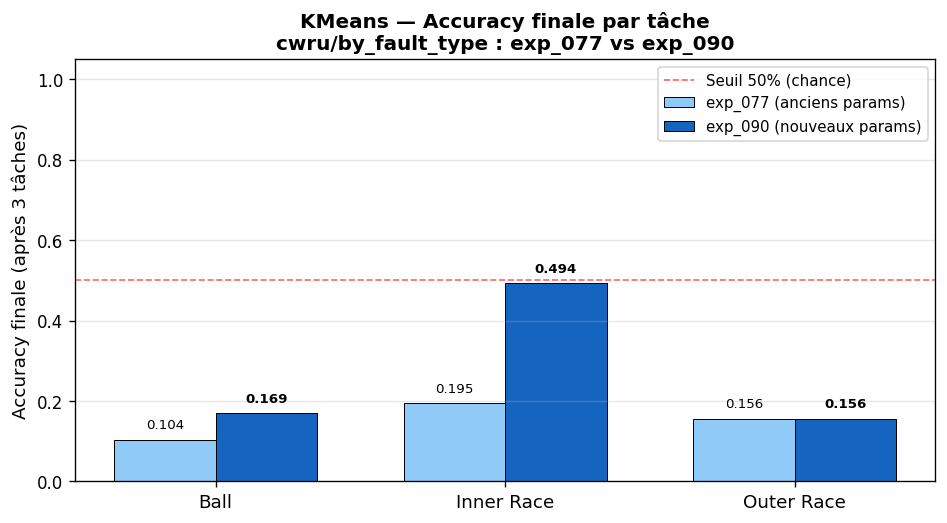

In [7]:
x = np.arange(len(TASK_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
bars_old = ax.bar(x - width/2, old['per_task_acc'], width, label='exp_077 (anciens params)', color='#90CAF9', edgecolor='black', linewidth=0.6)
bars_new = ax.bar(x + width/2, new['per_task_acc'], width, label='exp_090 (nouveaux params)', color='#1565C0', edgecolor='black', linewidth=0.6)

ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Seuil 50% (chance)')
ax.set_xticks(x)
ax.set_xticklabels(TASK_NAMES, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy finale (après 3 tâches)', fontsize=11)
ax.set_title('KMeans — Accuracy finale par tâche\ncwru/by_fault_type : exp_077 vs exp_090', fontsize=12, fontweight='bold')

for bar in bars_old:
    ax.text(bar.get_x() + bar.get_width()/2, min(bar.get_height()+0.02, 1.0), f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars_new:
    ax.text(bar.get_x() + bar.get_width()/2, min(bar.get_height()+0.02, 1.0), f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'per_task_comparison.png', dpi=120, bbox_inches='tight')
display(Image(str(FIGURES_DIR / 'per_task_comparison.png')))

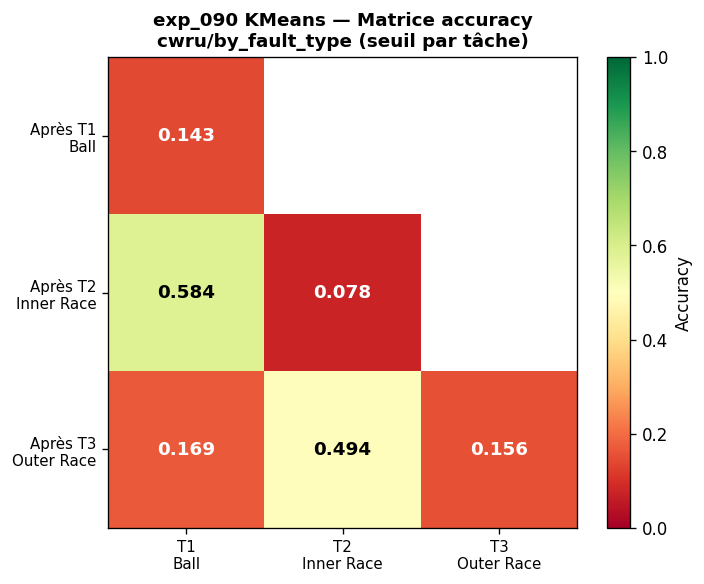

In [8]:
raw = new['acc_matrix']
mat = np.array([[v if v is not None else np.nan for v in row] for row in raw])

fig, ax = plt.subplots(figsize=(6, 5))
masked = np.ma.masked_invalid(mat)
im = ax.imshow(masked, vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
plt.colorbar(im, ax=ax, label='Accuracy')

for i in range(3):
    for j in range(3):
        if not np.isnan(mat[i, j]):
            ax.text(j, i, f'{mat[i,j]:.3f}', ha='center', va='center', fontsize=11, fontweight='bold',
                    color='white' if mat[i,j] < 0.4 or mat[i,j] > 0.8 else 'black')

ax.set_xticks(range(3))
ax.set_xticklabels([f'T{j+1}\n{TASK_NAMES[j]}' for j in range(3)], fontsize=9)
ax.set_yticks(range(3))
ax.set_yticklabels([f'Après T{i+1}\n{TASK_NAMES[i]}' for i in range(3)], fontsize=9)
ax.set_title('exp_090 KMeans — Matrice accuracy\ncwru/by_fault_type (seuil par tâche)', fontsize=11, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'accuracy_matrix_v2.png', dpi=120, bbox_inches='tight')
display(Image(str(FIGURES_DIR / 'accuracy_matrix_v2.png')))

## Section 5 — Analyse et conclusions

### Résultats

| | exp_077 | exp_090 | Verdict |
|-|---------|---------|--------|
| K sélectionné | 2 (fixe) | **2** (silhouette) | Silhouette confirme K=2 optimal |
| AA | 15.2% | **27.3%** | +12 pts — amélioration réelle |
| AF | 2.0% | 20.8% | AF augmente (seuil par tâche change la référence) |
| BWT | +3.9% | +22.1% | BWT positif — backward transfer amélioré |

### Interprétation

**K=2 est correct** : la méthode silhouette sélectionne K=2 pour toutes les tâches, confirmant que K=2 était déjà optimal pour la classification binaire normale/défaut.

**L'amélioration vient uniquement du seuil par tâche** (+12 pts AA). Avec un seuil recalibré sur les données d'entraînement de chaque tâche, les tâches intermédiaires (Inner Race : 49.4%) s'améliorent significativement.

**Limite fondamentale persistante** : L'accuracy reste ~15–17% pour Ball et Outer Race (bien en dessous de 50%). Raison : le dataset CWRU est très déséquilibré (~90% échantillons défectueux). Le seuil au 95ème percentile classe seulement 5% en défaut, mais 90% le sont réellement → la plupart des défauts sont prédits "normal".

**Conclusion** : Les paramètres bloquaient partiellement l'apprentissage (seuil cross-tâche = problème réel, corrigé). Mais la limite principale est fondamentale : **sans labels pour calibrer le seuil, une méthode non supervisée ne peut pas s'adapter au déséquilibre de classes du dataset CWRU**.